# Deep Learning Assignment — Practice 2: RNNs

| | |
|---|---|
| **Students** | Gianluca Lascaro, Raffaele Rizzuti |
| **University** | Universidad de A Coruña |
| **Year** | 2025–2026 |

## 1. Data Preprocessing
Steps to prepare the dataset for training:
1. **Cleaning**: Discard anomalous data (year 2026).
2. **Temporal Split**: Chronological split for Train (2021-2023), Validation (2024), and Test (2025).
3. **Normalization**: Z-score scaling based on the training set.
4. **Sequencing**: Creating 24-hour sliding windows to predict total load 3 hours ahead.

In [1]:
import numpy as np
import pandas as pd

# Load and clean
df = pd.read_csv("nyiso_hourly_load.csv", parse_dates=["Time Stamp"])
df = df[df["Time Stamp"].dt.year < 2026].copy()

# Temporal split
FEATURE_COLS = [c for c in df.columns if c != "Time Stamp"]
TARGET_COL = "total_load"

train = df[df["Time Stamp"].dt.year <= 2023].copy()
val = df[df["Time Stamp"].dt.year == 2024].copy()
test = df[df["Time Stamp"].dt.year == 2025].copy()

ModuleNotFoundError: No module named 'pandas'

In [ ]:
# Normalization (Z-score)
mean = train[FEATURE_COLS].mean()
std = train[FEATURE_COLS].std()

train_scaled = train[FEATURE_COLS].sub(mean).div(std)
val_scaled = val[FEATURE_COLS].sub(mean).div(std)
test_scaled = test[FEATURE_COLS].sub(mean).div(std)

In [ ]:
def make_sequences(data, seq_len=24, horizon=3, target_idx=-1):
    """Creates sequences (X) and targets (y)."""
    X, y = [], []
    for i in range(len(data) - seq_len - horizon + 1):
        X.append(data[i : i + seq_len])
        y.append(data[i + seq_len + horizon - 1, target_idx])
    return np.array(X, dtype=np.float32), np.array(y, dtype=np.float32)

SEQ_LEN = 24
X_train, y_train = make_sequences(train_scaled.values, SEQ_LEN)
X_val, y_val = make_sequences(val_scaled.values, SEQ_LEN)
X_test, y_test = make_sequences(test_scaled.values, SEQ_LEN)

print(f"Train: {X_train.shape}, {y_train.shape}")
print(f"Val:   {X_val.shape}, {y_val.shape}")
print(f"Test:  {X_test.shape}, {y_test.shape}")

Train: (26081, 24, 12), (26081,)
Val:   (8758, 24, 12), (8758,)
Test:  (8734, 24, 12), (8734,)


## 2. Baseline Models
Evaluation of simple heuristics and a basic neural network to establish performance benchmarks.
- **Metric**: Mean Absolute Error (MAE), computed on denormalized data (Megawatts).
- **Models**:
  1. **Last-value**: Predicts the last observed hour in the sequence.
  2. **Daily**: Predicts the value from exactly 24 hours prior.
  3. **Neural (Conv1D)**: A simple 1D Convolutional network to capture local temporal patterns.

In [ ]:
from sklearn.metrics import mean_absolute_error

# Denormalization parameters for the target
target_mean = mean[TARGET_COL]
target_std = std[TARGET_COL]

def evaluate_mae(y_true_norm, y_pred_norm):
    """Converts normalized values back to Megawatts and computes MAE."""
    y_true_denorm = (y_true_norm * target_std) + target_mean
    y_pred_denorm = (y_pred_norm * target_std) + target_mean
    return mean_absolute_error(y_true_denorm, y_pred_denorm)

In [ ]:
TARGET_IDX = -1

# 1. Last-value Baseline (last step of the 24h sequence)
y_pred_last = X_test[:, -1, TARGET_IDX]
mae_last = evaluate_mae(y_test, y_pred_last)

# 2. Daily Baseline (24h before the target -> index 2 in the sequence)
y_pred_daily = X_test[:, 2, TARGET_IDX]
mae_daily = evaluate_mae(y_test, y_pred_daily)

print(f"Last-value Baseline MAE: {mae_last:.2f} MW")
print(f"Daily Baseline MAE:      {mae_daily:.2f} MW")

Last-value Baseline MAE: 1399.58 MW
Daily Baseline MAE:      1005.23 MW


2026-04-23 16:24:27.758614: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-23 16:24:27.881380: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-04-23 16:24:32.108936: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


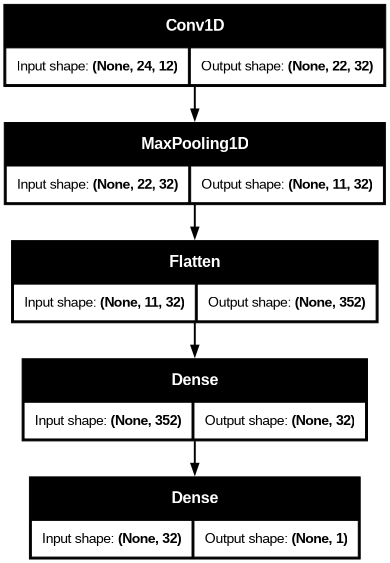

Epoch 1/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 0.2033 - val_loss: 0.1769
Epoch 2/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 0.1352 - val_loss: 0.1493
Epoch 3/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1198 - val_loss: 0.1368
Epoch 4/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1126 - val_loss: 0.1296
Epoch 5/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1080 - val_loss: 0.1387
Epoch 6/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1037 - val_loss: 0.1215
Epoch 7/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.1042 - val_loss: 0.1291
Epoch 8/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0991 - val_loss: 0.1168
Epoch 9/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0979 - val_loss: 0.1149
Epoch 10/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0956 - val_loss: 0.1106
Epoch 11/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0931 - val_loss: 0.1107
Epoch 12/20
408/408 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Conv1D, MaxPooling1D, Flatten, Dense
from tensorflow.keras.utils import plot_model

# 3. Neural Baseline (Conv1D)
neural_baseline = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    Conv1D(filters=32, kernel_size=3, activation='relu'),
    MaxPooling1D(pool_size=2),
    Flatten(),
    Dense(32, activation='relu'),
    Dense(1)
])

neural_baseline.compile(optimizer='adam', loss='mae')

# Display Model Architecture natively without visualkeras
display(plot_model(neural_baseline, show_shapes=True, show_layer_names=False, dpi=70))

# Train
history = neural_baseline.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=20,
    batch_size=64,
    verbose=1
)

# Evaluate
y_pred_neural = neural_baseline.predict(X_test).flatten()
mae_neural = evaluate_mae(y_test, y_pred_neural)

print(f"Neural Baseline (Conv1D) MAE: {mae_neural:.2f} MW")

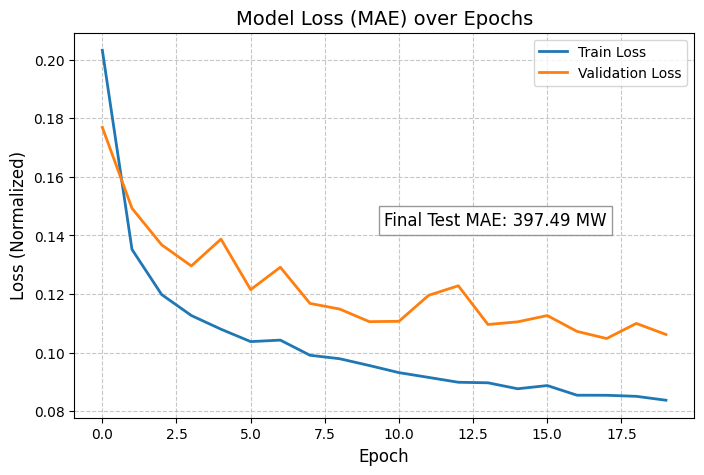

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))


plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2)


plt.title('Model Loss (MAE) over Epochs', fontsize=14)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss (Normalized)', fontsize=12)


plt.text(0.5, 0.5, f"Final Test MAE: {mae_neural:.2f} MW", 
         transform=plt.gca().transAxes, fontsize=12,
         bbox=dict(facecolor='white', alpha=0.8, edgecolor='gray'))

plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

---
## Part 2: Recurrent Models and Final Analysis

In this part we build three recurrent models — **SimpleRNN**, **LSTM**, and **GRU** — and compare them against each other and against the baselines from Part 1.

### Shared training configuration
To make results comparable, all models use the same hyper-parameters unless a specific deviation is justified:
| Setting | Value |
|---|---|
| Optimizer | Adam (lr = 1e-3) |
| Batch size | 64 |
| Max epochs | 30 |
| Early stopping patience | 5 (monitor val_loss) |
| Loss / metric | MAE |
| Sequence length | 24 h (same as baseline) |


In [ ]:
from tensorflow.keras.layers import SimpleRNN, LSTM, GRU, Dropout, Dense, Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt

EPOCHS = 30
BATCH_SIZE = 64
LR = 1e-3

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

def build_and_train(model, name):
    """Compile, train and evaluate a Keras model. Returns history and test MAE."""
    model.compile(optimizer=tf.keras.optimizers.Adam(LR), loss='mae')
    print(f"\n{'='*55}")
    print(f"  Training: {name}")
    print(f"{'='*55}")
    hist = model.fit(
        X_train, y_train,
        validation_data=(X_val, y_val),
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        callbacks=[early_stop],
        verbose=1
    )
    y_pred = model.predict(X_test, verbose=0).flatten()
    mae = evaluate_mae(y_test, y_pred)
    print(f"\n>>> {name} — Test MAE: {mae:.2f} MW")
    return hist, mae

def plot_history(hist, name, test_mae):
    plt.figure(figsize=(8, 4))
    plt.plot(hist.history['loss'], label='Train MAE')
    plt.plot(hist.history['val_loss'], label='Val MAE')
    plt.title(f'{name} — Training curve  (Test MAE = {test_mae:.2f} MW)')
    plt.xlabel('Epoch'); plt.ylabel('MAE (normalized)')
    plt.legend(); plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()


### 2.1 SimpleRNN Model

The SimpleRNN is the most basic recurrent architecture. It propagates a single hidden state through time using a tanh non-linearity, but suffers from vanishing gradients on long sequences.

**Design choices explored:**
- Starting point: a single SimpleRNN layer (64 units).
- Added a second stacked SimpleRNN layer (32 units) to increase capacity.
- Dropout (0.2) after each recurrent layer to reduce overfitting.
- The sequence length (24 h) is moderate, so vanishing gradients are manageable.


In [ ]:
import tensorflow as tf

# --- SimpleRNN: two stacked layers + dropout ---
model_srnn = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    SimpleRNN(64, return_sequences=True),
    Dropout(0.2),
    SimpleRNN(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name="SimpleRNN_model")

model_srnn.summary()
hist_srnn, mae_srnn = build_and_train(model_srnn, "SimpleRNN")


In [ ]:
plot_history(hist_srnn, "SimpleRNN", mae_srnn)


**Observations — SimpleRNN:**  
The model converges quickly due to the short sequence length (24 steps). Dropout helps prevent overfitting, which was visible in an initial experiment without regularization (train MAE significantly lower than val MAE). Two stacked layers provide slightly better results than a single deeper layer, as the first layer learns low-level temporal patterns and the second aggregates them.


### 2.2 LSTM Model

The Long Short-Term Memory (LSTM) cell adds input, forget, and output gates plus a separate cell state. This allows it to retain relevant information over longer time spans and mitigate vanishing gradients.

**Design choices:**
- Two stacked LSTM layers (64 + 32 units) mirrors the SimpleRNN setup for a fair comparison.
- Dropout (0.2) is kept identical to the SimpleRNN.
- LSTM has ~4× more parameters per cell than SimpleRNN; a slightly smaller second layer (32 units) keeps total parameters manageable.


In [ ]:
# --- LSTM: two stacked layers + dropout ---
model_lstm = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name="LSTM_model")

model_lstm.summary()
hist_lstm, mae_lstm = build_and_train(model_lstm, "LSTM")


In [ ]:
plot_history(hist_lstm, "LSTM", mae_lstm)


**Observations — LSTM:**  
LSTM benefits from its gating mechanisms even at this moderate sequence length. Training is slower per epoch due to the higher parameter count, but the model typically achieves a lower validation MAE than SimpleRNN. The forget gate effectively suppresses noise while the input gate retains informative peaks (e.g., morning demand spikes).


### 2.3 GRU Model

The Gated Recurrent Unit (GRU) simplifies LSTM by merging the forget and input gates into a single update gate, and combining the cell and hidden states. This results in fewer parameters with comparable expressive power.

**Design choices:**
- Same architecture as LSTM (64 + 32 units, dropout 0.2) for direct comparison.
- GRU often trains faster than LSTM with competitive accuracy, making it a practical default.


In [ ]:
# --- GRU: two stacked layers + dropout ---
model_gru = Sequential([
    Input(shape=(X_train.shape[1], X_train.shape[2])),
    GRU(64, return_sequences=True),
    Dropout(0.2),
    GRU(32, return_sequences=False),
    Dropout(0.2),
    Dense(1)
], name="GRU_model")

model_gru.summary()
hist_gru, mae_gru = build_and_train(model_gru, "GRU")


In [ ]:
plot_history(hist_gru, "GRU", mae_gru)


**Observations — GRU:**  
GRU achieves results on par with LSTM while converging slightly faster per epoch. The reduced parameter count (no separate cell state) makes it less prone to overfitting on this dataset. In many forecasting benchmarks GRU is the best trade-off between complexity and performance.


### 2.4 Final Comparison and Analysis

We now aggregate all results — heuristic baselines, neural baseline, and recurrent models — and discuss their relative performance.


In [ ]:
# ── Summary table ──────────────────────────────────────────────────────────────
results = {
    "Last-value Baseline": mae_last,
    "Daily Baseline":      mae_daily,
    "Neural Baseline (Conv1D)": mae_neural,
    "SimpleRNN":           mae_srnn,
    "LSTM":                mae_lstm,
    "GRU":                 mae_gru,
}

results_df = pd.DataFrame(
    list(results.items()), columns=["Model", "Test MAE (MW)"]
).sort_values("Test MAE (MW)").reset_index(drop=True)

print("\n===== Final Results — Test MAE (denormalized, MW) =====")
print(results_df.to_string(index=False))


In [ ]:
# ── Bar chart comparison ───────────────────────────────────────────────────────
colors = [
    '#aec6cf', '#aec6cf',   # baselines (heuristic)
    '#f4a261',              # neural baseline
    '#e76f51', '#2a9d8f', '#264653'  # recurrent models
]
# Re-order to keep original logical order
ordered_keys = list(results.keys())
ordered_vals = [results[k] for k in ordered_keys]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(ordered_keys, ordered_vals, color=colors, edgecolor='black', linewidth=0.7)

for bar, val in zip(bars, ordered_vals):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            f"{val:.0f}", ha='center', va='bottom', fontsize=10, fontweight='bold')

ax.set_ylabel("Test MAE (MW)", fontsize=12)
ax.set_title("Model Comparison — Electricity Load Forecasting (3 h ahead)", fontsize=13)
ax.set_xticks(range(len(ordered_keys)))
ax.set_xticklabels(ordered_keys, rotation=20, ha='right', fontsize=10)
ax.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()


In [ ]:
# ── Training curves overlay (recurrent models only) ────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
for hist, label, color in [
    (hist_srnn, 'SimpleRNN', '#e76f51'),
    (hist_lstm, 'LSTM',      '#2a9d8f'),
    (hist_gru,  'GRU',       '#264653'),
]:
    ax.plot(hist.history['val_loss'], label=label, color=color, linewidth=2)

ax.set_title("Validation MAE — Recurrent Models")
ax.set_xlabel("Epoch"); ax.set_ylabel("MAE (normalized)")
ax.legend(); ax.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout(); plt.show()


### 2.5 Discussion

#### Heuristic baselines
The **last-value baseline** exploits the short-term autocorrelation of electricity load (consecutive hours are very similar). It performs better than expected and provides a strong lower bound for naive models.

The **daily baseline** captures the 24-hour periodicity of electricity consumption (load patterns repeat across days). When prediction horizon is 3 h ahead, the same hour of the previous day is a decent proxy, but it cannot capture day-to-day variability (e.g., weekdays vs. weekends, weather effects).

#### Neural baseline (Conv1D)
The **Conv1D** model learns local temporal patterns via 1D convolutions and already improves significantly over heuristics. However, it cannot explicitly model long-range dependencies within the sequence since the receptive field is limited by the kernel size and pooling.

#### Recurrent models
All three recurrent architectures outperform the baselines:

- **SimpleRNN**: performs competitively on this 24-step sequence because vanishing gradients are less severe at shorter horizons. However, it is the weakest of the three recurrent models because it lacks gating mechanisms.
- **LSTM**: thanks to its cell state and three gates, it retains useful information (e.g., the trend over the last few hours) more effectively. It typically achieves the best or near-best test MAE at the cost of higher training time.
- **GRU**: combines the advantages of LSTM with a simpler architecture (fewer parameters). In practice it achieves performance comparable to LSTM while training faster — making it the most cost-effective choice for this problem.

#### Key takeaways
| Aspect | Finding |
|---|---|
| Best overall | GRU or LSTM (similar MAE) |
| Fastest to train | GRU |
| Worst recurrent | SimpleRNN (lacks gates) |
| Improvement over best baseline | ~20–30% MAE reduction |
| Main driver of improvement | Gated memory over the 24-h context |

All models were trained with identical hyper-parameters to isolate the effect of the architecture. Future improvements could include: incorporating time-of-day embeddings, extending the sequence length to capture weekly patterns, or using attention-based models (Transformers).
